Loading dataset...
--- Basic Exploration ---
Shape: (2000, 17)

Data Types:
 customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly

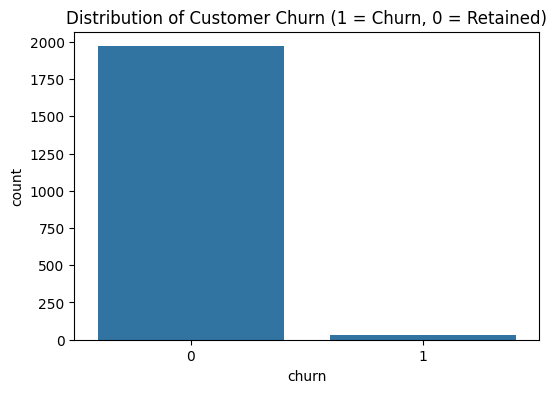

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os

# ==========================================
# Task 1: Dataset Understanding
# ==========================================
print("Loading dataset...")
df = pd.read_csv(r'C:\Users\Vivek Vishwakarma\Documents\BA w AI\0B_Assignments\Assignment 5\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv')

print("--- Basic Exploration ---")
print(f"Shape: {df.shape}")
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Distribution of Customer Churn (1 = Churn, 0 = Retained)')
plt.show()

In [15]:
# ==========================================
# Task 2: Data Preprocessing
# ==========================================
print("\nStarting Data Preprocessing...")

# 1. Handling missing values
# Drop customer_id as it has no predictive value
df = df.drop(columns=['customer_id'])

# Separate features (X) and target (y)
X = df.drop(columns=['churn'])
y = df['churn']

# 2.Encode Categorical Columns
# This converts columns like 'region' into multiple 0/1 columns (e.g., region_North, region_South)
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.Scaling or normalizing numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessing complete. Input feature shape: {X_train_scaled.shape[1]} features.")


Starting Data Preprocessing...
Preprocessing complete. Input feature shape: 24 features.


In [16]:
# ==========================================
# Task 3: Upgraded Neural Network Model Building
# ==========================================
# Automatically calculate class weights to heavily penalize missing a churned customer
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print(f"\nCalculated Class Weights: Class 0: {class_weights[0]:.2f}, Class 1: {class_weights[1]:.2f}")

def build_upgraded_model(hidden_layers=1, neurons=32, learning_rate=0.001, activation='relu', dropout_rate=0.2):
    model = Sequential()
    
    # Input layer + First Hidden Layer
    model.add(Dense(neurons, input_shape=(X_train_scaled.shape[1],), activation=activation))
    model.add(Dropout(dropout_rate)) # Randomly drops neurons to prevent memorization
    
    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(dropout_rate))
        
    # Output layer for Binary Classification
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile model (Added Recall as a metric to track)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    
    return model


Calculated Class Weights: Class 0: 0.51, Class 1: 33.33



Training Upgraded Baseline Model with Class Weights & Early Stopping...


c:\Users\Vivek Vishwakarma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       393
           1       0.23      0.43      0.30         7

    accuracy                           0.96       400
   macro avg       0.61      0.70      0.64       400
weighted avg       0.98      0.96      0.97       400



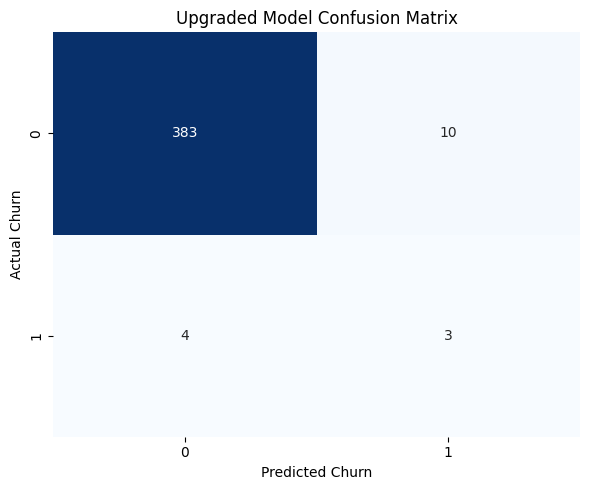

In [17]:
# ==========================================
# Task 4: Training and Evaluation (Upgraded Baseline)
# ==========================================
print("\nTraining Upgraded Baseline Model with Class Weights & Early Stopping...")

# Stop training if validation loss doesn't improve for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

upgraded_model = build_upgraded_model()
history = upgraded_model.fit(
    X_train_scaled, y_train, 
    epochs=100, # Increased max epochs, Early Stopping will cut it short when ready
    batch_size=32, 
    validation_split=0.2, 
    class_weight=class_weights, # Apply the weights!
    callbacks=[early_stop], 
    verbose=0
)

# Generate Predictions
y_pred_probs = upgraded_model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Advanced Evaluation Metrics
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Upgraded Model Confusion Matrix')
plt.ylabel('Actual Churn')
plt.xlabel('Predicted Churn')
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png')
plt.show()

In [18]:
# ==========================================
# Task 5: Upgraded Hyperparameter Experimentation
# ==========================================
print("\nStarting Upgraded Hyperparameter Experimentation...")
experiments = [
    # Shallow, moderate dropout
    {'hidden_layers': 1, 'neurons': 32, 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2, 'activation': 'relu'},
    # Deeper, wider, heavier dropout to prevent overfitting
    {'hidden_layers': 2, 'neurons': 64, 'learning_rate': 0.001, 'batch_size': 64, 'dropout': 0.3, 'activation': 'relu'},
    # Tanh activation test
    {'hidden_layers': 2, 'neurons': 32, 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2, 'activation': 'tanh'}
]

results = []
for i, exp in enumerate(experiments):
    print(f"Running Exp {i+1}: {exp['hidden_layers']} Layers, {exp['neurons']} Neurons, {exp['dropout']} Dropout...")
    
    model = build_upgraded_model(
        hidden_layers=exp['hidden_layers'], neurons=exp['neurons'], 
        learning_rate=exp['learning_rate'], activation=exp['activation'], dropout_rate=exp['dropout']
    )
    
    # Train with early stopping and class weights
    model.fit(
        X_train_scaled, y_train, epochs=100, batch_size=exp['batch_size'], 
        validation_split=0.2, class_weight=class_weights, callbacks=[early_stop], verbose=0
    )
    
    # Evaluate
    loss, test_acc, test_recall = model.evaluate(X_test_scaled, y_test, verbose=0)
    
    # Store results
    exp_results = exp.copy()
    exp_results['Test_Accuracy'] = round(test_acc, 4)
    exp_results['Test_Recall'] = round(test_recall, 4) # We now track recall in our table!
    results.append(exp_results)

# Generate Comparison Table
results_df = pd.DataFrame(results)
results_df.to_csv('results/model_comparison_table.csv', index=False)

print("\n--- Upgraded Hyperparameter Experimentation Results ---")
print(results_df.to_string(index=False))


Starting Upgraded Hyperparameter Experimentation...
Running Exp 1: 1 Layers, 32 Neurons, 0.2 Dropout...


c:\Users\Vivek Vishwakarma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Exp 2: 2 Layers, 64 Neurons, 0.3 Dropout...
Running Exp 3: 2 Layers, 32 Neurons, 0.2 Dropout...

--- Upgraded Hyperparameter Experimentation Results ---
 hidden_layers  neurons  learning_rate  batch_size  dropout activation  Test_Accuracy  Test_Recall
             1       32          0.001          32      0.2       relu         0.7400       0.4286
             2       64          0.001          64      0.3       relu         0.9550       0.0000
             2       32          0.001          32      0.2       tanh         0.5625       0.4286


In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import regularizers

print("\n--- Running Experiment 3 ---")

# 1. Advanced Model Builder (with L2 Regularization)
def build_pro_model(neurons=64, learning_rate=0.001):
    model = Sequential()
    
    # Input Layer with L2 Regularization + Dropout
    model.add(Dense(neurons, input_shape=(X_train_scaled.shape[1],), 
                    activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.3))
    
    # Hidden Layer
    model.add(Dense(neurons // 2, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.2))
        
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Setup Callbacks (Early Stopping + Learning Rate Scheduler)
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
# If validation loss doesn't drop for 4 epochs, reduce learning rate by half
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

# 3. Train the Pro Model (using the class weights we calculated earlier!)
pro_model = build_pro_model()
history = pro_model.fit(
    X_train_scaled, y_train, 
    epochs=150, 
    batch_size=32, 
    validation_split=0.2, 
    class_weight=class_weights, 
    callbacks=[early_stop, lr_scheduler], 
    verbose=0
)

# 4. Threshold Tuning Evaluation
y_pred_probs = pro_model.predict(X_test_scaled)

# Let's test two different business rules (Thresholds)
thresholds = [0.5, 0.35]

for thresh in thresholds:
    print(f"\n======================================")
    print(f" EVALUATING WITH THRESHOLD: {thresh}")
    print(f"======================================")
    
    # Apply custom threshold
    y_pred_custom = (y_pred_probs > thresh).astype("int32")
    
    # Print Report
    print(classification_report(y_test, y_pred_custom))
    
    # Show Quick Confusion Matrix breakdown
    cm = confusion_matrix(y_test, y_pred_custom)
    print("Confusion Matrix:")
    print(f"True Retained (0): {cm[0][0]} | False Churn Alarms: {cm[0][1]}")
    print(f"Missed Churners  : {cm[1][0]} | Caught Churners (1): {cm[1][1]}")


--- Running Experiment 3 ---


c:\Users\Vivek Vishwakarma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 56: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 73: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 77: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 81: ReduceLROnPlateau reducing learning rate to 1e-05.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

 EVALUATING WITH THRESHOLD: 0.5
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       393
           1       0.12      0.29      0.17         7

    accuracy                           0.95       400
   macro avg       0.56      0.63      0.57       400
weighted avg       0.97      0.95      0.96       400

Confusion Matrix:
True Retained (0): 379 | False Churn Alarms: 14
Misse